In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Exploratory Data Analysis

In [2]:
df = pd.read_csv('./archive (5)/used_car_dataset.csv')
df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [3]:
df.shape

(9582, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         9582 non-null   object
 1   model         9582 non-null   object
 2   Year          9582 non-null   int64 
 3   Age           9582 non-null   int64 
 4   kmDriven      9535 non-null   object
 5   Transmission  9582 non-null   object
 6   Owner         9582 non-null   object
 7   FuelType      9582 non-null   object
 8   PostedDate    9582 non-null   object
 9   AdditionInfo  9582 non-null   object
 10  AskPrice      9582 non-null   object
dtypes: int64(2), object(9)
memory usage: 823.6+ KB


In [5]:
# Menghapus karakter yang bukan angka di kolom kmDriven
df['kmDriven'] = df['kmDriven'].astype(str)
df['kmDriven'] = df['kmDriven'].str.replace(r'\D', '', regex=True)

# Mengubah tipe data kmDriven
df['kmDriven'] = pd.to_numeric(df['kmDriven'], errors='coerce')

# Menghapus karakter yang bukan angka di kolom AskPrice
df['AskPrice'] = df['AskPrice'].astype(str)
df['AskPrice'] = df['AskPrice'].str.replace(r'\D', '', regex=True)

# Mengubah tipe data AskPrice
df['AskPrice'] = pd.to_numeric(df['AskPrice'], errors='coerce')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         9582 non-null   object 
 1   model         9582 non-null   object 
 2   Year          9582 non-null   int64  
 3   Age           9582 non-null   int64  
 4   kmDriven      9535 non-null   float64
 5   Transmission  9582 non-null   object 
 6   Owner         9582 non-null   object 
 7   FuelType      9582 non-null   object 
 8   PostedDate    9582 non-null   object 
 9   AdditionInfo  9582 non-null   object 
 10  AskPrice      9582 non-null   int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 823.6+ KB


# Data Preprocessing

In [7]:
df = df.drop(columns=['Year', 'PostedDate', 'AdditionInfo'])
df.head()

,Brand,model,Age,kmDriven,Transmission,Owner,FuelType,AskPrice
0,Honda,City,23,98000.0,Manual,second,Petrol,195000
1,Toyota,Innova,15,1900000.0,Manual,second,Diesel,375000
2,Volkswagen,VentoTest,14,77246.0,Manual,first,Diesel,184999
3,Maruti Suzuki,Swift,7,83500.0,Manual,second,Diesel,565000
4,Maruti Suzuki,Baleno,5,45000.0,Automatic,first,Petrol,685000


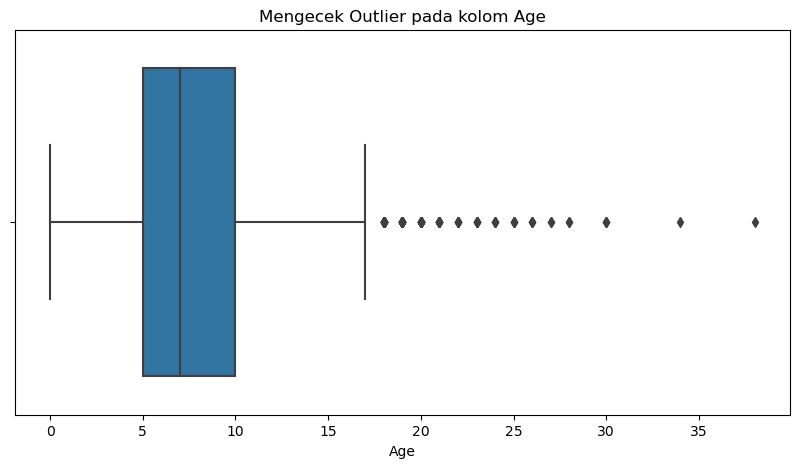

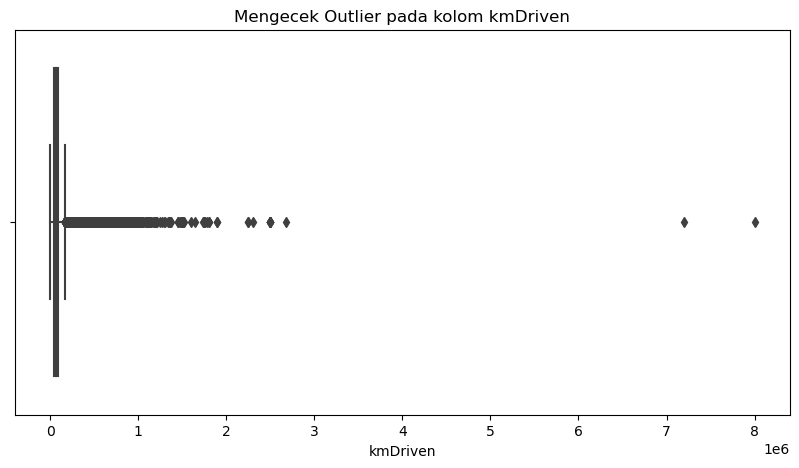

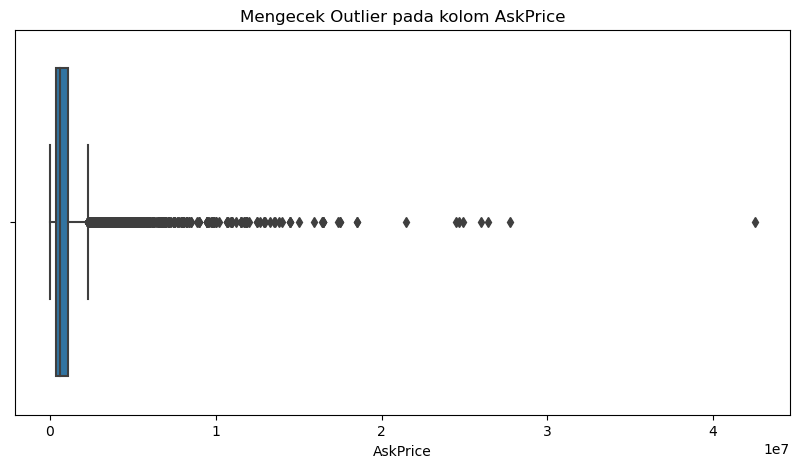

In [8]:
cols = ['Age', 'kmDriven', 'AskPrice']

for i in cols:
  plt.figure(figsize=(10, 5))
  sns.boxplot(x=df[i])
  plt.title(f'Mengecek Outlier pada kolom {i}')
  plt.show()

In [9]:
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

In [10]:
condition = ~((df[cols] < lower_bound) | (df[cols] > upper_bound)).any(axis=1)
df_copy = df[condition].copy()

In [11]:
print(f'Jumlah data asli : {df.shape}')
print(f'Jumlah data bersih : {df_copy.shape}')

Jumlah data asli : (9582, 8)
Jumlah data bersih : (7722, 8)


In [12]:
df_copy.isnull().sum()

Brand            0
model            0
Age              0
kmDriven        43
Transmission     0
Owner            0
FuelType         0
AskPrice         0
dtype: int64

In [13]:
df_copy = df_copy.dropna()
df_copy.isnull().sum()

Brand           0
model           0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
AskPrice        0
dtype: int64

In [14]:
df_copy.duplicated().sum()

623

In [15]:
df_copy = df_copy.drop_duplicates()
df_copy.duplicated().sum()

0

In [16]:
kolom_kategori = df_copy.select_dtypes(include='object').columns
print(f'Kolom Kategori: {list(kolom_kategori)}')

Kolom Kategori: ['Brand', 'model', 'Transmission', 'Owner', 'FuelType']


In [17]:
for col in kolom_kategori:
  jumlah_data_unik = df_copy[col].nunique()
  print(f'Kolom {col} memiliki {jumlah_data_unik} kategori')

  if jumlah_data_unik < 10:
    print(f'Isinya : {df_copy[col].unique()}')
  else:
    print(f'Isinya terlalu banyak')
  print('-' * 30)

Kolom Brand memiliki 33 kategori
Isinya terlalu banyak
------------------------------
Kolom model memiliki 306 kategori
Isinya terlalu banyak
------------------------------
Kolom Transmission memiliki 2 kategori
Isinya : ['Manual' 'Automatic']
------------------------------
Kolom Owner memiliki 2 kategori
Isinya : ['first' 'second']
------------------------------
Kolom FuelType memiliki 3 kategori
Isinya : ['Diesel' 'Petrol' 'Hybrid/CNG']
------------------------------


In [18]:
# Map encoding
owner_map = {
    'first': 1,
    'second': 2
}

df_copy['Owner_Encode'] = df_copy['Owner'].map(owner_map)

In [19]:
df_copy = df_copy.drop(columns='Owner')
df_copy.head()

,Brand,model,Age,kmDriven,Transmission,FuelType,AskPrice,Owner_Encode
2,Volkswagen,VentoTest,14,77246.0,Manual,Diesel,184999,1
3,Maruti Suzuki,Swift,7,83500.0,Manual,Diesel,565000,2
4,Maruti Suzuki,Baleno,5,45000.0,Automatic,Petrol,685000,1
5,BMW,X3,10,83000.0,Automatic,Diesel,1350000,1
6,Toyota,Innova,10,168000.0,Manual,Diesel,1025000,2


In [20]:
# Frequence encoding
freq_brand = df_copy['Brand'].value_counts().to_dict()
df_copy['Brand_Freq'] = df_copy['Brand'].map(freq_brand)

freq_brand = df_copy['model'].value_counts().to_dict()
df_copy['model_Freq'] = df_copy['model'].map(freq_brand)

df_copy = df_copy.drop(columns=['Brand', 'model'])
df_copy.head()

,Age,kmDriven,Transmission,FuelType,AskPrice,Owner_Encode,Brand_Freq,model_Freq
2,14,77246.0,Manual,Diesel,184999,1,237,70
3,7,83500.0,Manual,Diesel,565000,2,2293,238
4,5,45000.0,Automatic,Petrol,685000,1,2293,151
5,10,83000.0,Automatic,Diesel,1350000,1,114,10
6,10,168000.0,Manual,Diesel,1025000,2,410,60


In [21]:
# One Hot encoding
df_copy = pd.get_dummies(df_copy, columns=['Transmission', 'FuelType'], drop_first=True, dtype=int)
df_copy.head()

,Age,kmDriven,AskPrice,Owner_Encode,Brand_Freq,model_Freq,Transmission_Manual,FuelType_Hybrid/CNG,FuelType_Petrol
2,14,77246.0,184999,1,237,70,1,0,0
3,7,83500.0,565000,2,2293,238,1,0,0
4,5,45000.0,685000,1,2293,151,0,0,1
5,10,83000.0,1350000,1,114,10,0,0,0
6,10,168000.0,1025000,2,410,60,1,0,0


In [22]:
X = df_copy.drop(columns='AskPrice')
y = df_copy['AskPrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Total data asli: {df_copy.shape}')
print(f'Total data latih: {X_train.shape}')
print(f'Total data uji: {X_test.shape}')

Total data asli: (7056, 9)
Total data latih: (5644, 8)
Total data uji: (1412, 8)


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeling

In [24]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [25]:
y_predict = rf_model.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_predict)
r2_rf = r2_score(y_test, y_predict)

print('=' * 30)
print(f'Hasil Evaluasi model random forest')
print('=' * 30)
print(f'Mean Absolute Error = {mae_rf:,.0f}')
print(f'R2 Score = {r2_rf:.2f}')

Hasil Evaluasi model random forest
Mean Absolute Error = 120,488
R2 Score = 0.84


Brand_Freq             0.309454
Age                    0.290558
model_Freq             0.178972
Transmission_Manual    0.087214
kmDriven               0.071950
FuelType_Hybrid/CNG    0.026952
FuelType_Petrol        0.026428
Owner_Encode           0.008473
dtype: float64


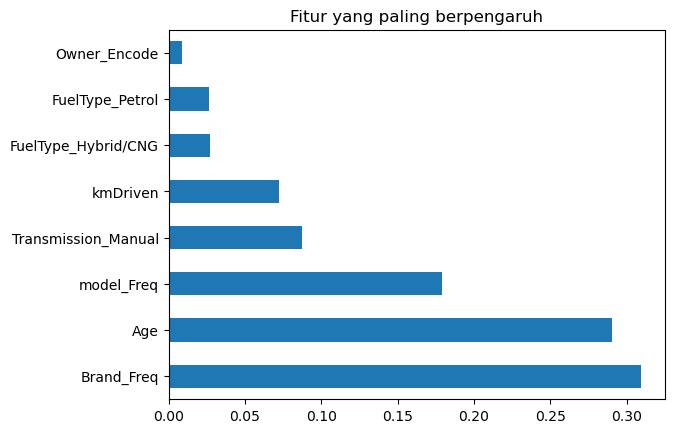

In [26]:
fi = pd.Series(rf_model.feature_importances_, index=X.columns)

print(fi.nlargest(10))

fi.nlargest(10).plot(kind='barh')
plt.title('Fitur yang paling berpengaruh')
plt.show()

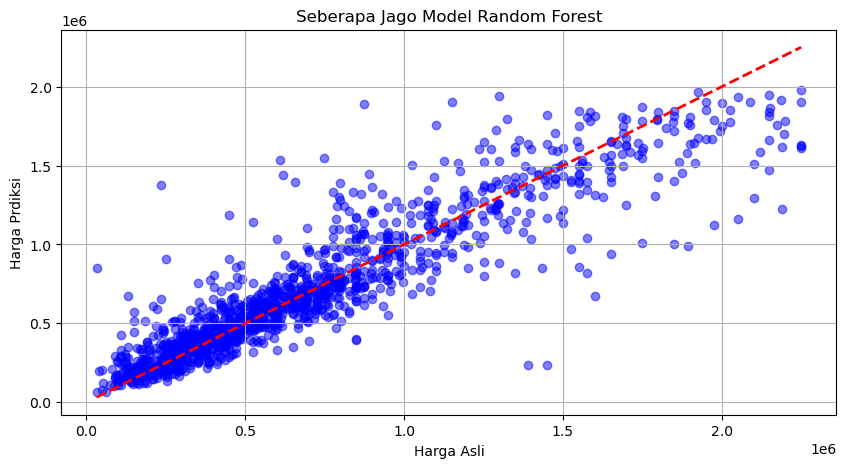

In [27]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_predict, alpha=0.5, color='blue')

min_val = min(y_test.min(), y_predict.min())
max_val = max(y_test.max(), y_predict.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
plt.xlabel('Harga Asli')
plt.ylabel('Harga Prdiksi')
plt.title('Seberapa Jago Model Random Forest')
plt.grid(True)
plt.show()

In [28]:
korelasi = df[['Age', 'AskPrice']].corr().iloc[0, 1]
print(f'Korelasi Umur dengan Harg Mobil : {korelasi:.2f}')

Korelasi Umur dengan Harg Mobil : -0.30


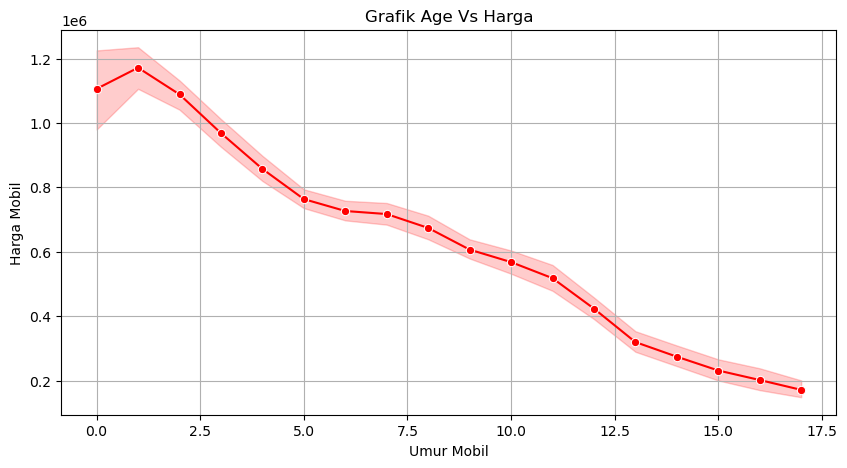

In [29]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='Age', y='AskPrice', data=df_copy, marker='o', color='red')
plt.title('Grafik Age Vs Harga')
plt.xlabel('Umur Mobil')
plt.ylabel('Harga Mobil')
plt.grid(True)
plt.show()

In [30]:
import joblib

# Simpan scaler dan model sekaligus
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(rf_model, 'rf_model.joblib')

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [31]:
print(X_train.columns.tolist())

['Age', 'kmDriven', 'Owner_Encode', 'Brand_Freq', 'model_Freq', 'Transmission_Manual', 'FuelType_Hybrid/CNG', 'FuelType_Petrol']
